In [1]:
##Do not touch unless adding in additional packages
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import SymLogNorm
from IPython.display import HTML, display
import pandas as pd

from landlab import RasterModelGrid
from landlab.components import (
    PriorityFloodFlowRouter, SpaceLargeScaleEroder, SpatialPrecipitationDistribution,
    LateralEroder, Space, DepressionFinderAndRouter, FlowAccumulator, OverlandFlow
)
from landlab.plot import imshowhs_grid
import os

In [2]:
def initialize_grid():
    mg = RasterModelGrid((100, 50), xy_spacing=10.0)  # Grid spacing now meters

    ##Do not edit
    z = mg.add_zeros("topographic__elevation", at="node")
    x = mg.node_x
    y = mg.node_y
    grid_width = x.max()
    grid_height = y.max()
    center_x = grid_width / 2

    # Elevation shaping
    slope_profile = 20.0 * (y / grid_height) ** 2
    valley = -3.0003 * np.exp(-((x - center_x) ** 2) / (2 * (200 ** 2)))

    growth = 2.0 * (
        np.exp(-(((x - 100) ** 2 + (y - 100) ** 2) / (2 * 100 ** 2))) +
        np.exp(-(((x - (grid_width - 100)) ** 2 + (y - 100) ** 2) / (2 * 100 ** 2))) +
        np.exp(-(((x - 10) ** 2 + (y - grid_height) ** 2) / (2 * 100 ** 2))) +
        np.exp(-(((x - (grid_width - 10)) ** 2 + (y - grid_height) ** 2) / (2 * 100 ** 2)))
    )

    z += slope_profile + valley + growth
    z += np.random.normal(scale=0.06, size=z.size)  # Z: Elevation

    s = mg.add_zeros("soil__depth", at="node", dtype=float)
    s += 0.3
    z += s

    ##Do not touch unless you want to adjust your watershed outlet
    mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
    bottom_nodes = mg.nodes_at_bottom_edge
    bottom_center = bottom_nodes[len(bottom_nodes) // 2]
    mg.status_at_node[bottom_center] = mg.BC_NODE_IS_FIXED_VALUE

    return mg

In [3]:
def run_model_with_animation(mg, rain, label, n_steps, dt, uplift_rate=0.00002, every_n=50):##. mm = 1mm/yr
    mg.add_field("water__unit_flux_in", rain, at="node", clobber=True)
    
    ###Above alter rain for different climate regimes, .5 for semi-arid, rain for humid continental:, 2 for semi-tropical###
###the default rain is 1m/yr which is perfect for this
    
    fr = PriorityFloodFlowRouter(mg, flow_metric="D8", update_flow_depressions=True)
    ha = SpaceLargeScaleEroder(mg, K_sed=5e-6, K_br=1e-6, phi=0.4, H_star=1.0)

    artists = []
    fig, ax = plt.subplots(figsize=(6, 6))

    # rainfall tally tracker
    rainfall_records = []

    for step in tqdm(range(n_steps), desc=f"Running model: {label}"):
        fr.run_one_step()
        ha.run_one_step(dt)

        # ensure bedrock field exists before trying to update
        if "bedrock__elevation" in mg.at_node:
            mg.at_node["bedrock__elevation"][mg.core_nodes] += uplift_rate * dt
        else:
            # create bedrock field based on topographic__elevation - soil__depth if necessary
            mg.add_field("bedrock__elevation", mg.at_node["topographic__elevation"] - mg.at_node["soil__depth"], at="node", clobber=True)
            mg.at_node["bedrock__elevation"][mg.core_nodes] += uplift_rate * dt

        mg.at_node["topographic__elevation"][:] = (
            mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
        )

        # Record rainfall total every step (scaled to meters/year * dt years)
        rain_total = np.mean(rain) * dt   # avg rainfall over domain * years
        rainfall_records.append({
            "Step": step,
            "Model Time (years)": step * dt,
            "Total Rain (m)": rain_total
        })

        if step % every_n == 0:
            elev_raster = mg.node_vector_to_raster(mg.at_node["topographic__elevation"])
            im = ax.imshow(elev_raster, cmap="terrain", origin="lower",
                           extent=[0, mg.extent[1]/1000, 0, mg.extent[0]/1000],  # km scale
                           animated=True, aspect="auto")
            title = ax.text(2, 5, f"Step {step}", color='white', fontsize=10, animated=True)
            artists.append([im, title])

    ani = animation.ArtistAnimation(fig, artists, interval=200, blit=True)
    plt.close(fig)

    # convert rainfall tally to DataFrame and print as table (every step = 2000 yrs if dt=2000)
    df = pd.DataFrame(rainfall_records)
    #print(f"\nRainfall Tally for {label} (per {dt} years step):")
    #display(df.head(15))  # show first few rows

    return mg, ani

In [4]:

# ========== Flow Routing and Lateral Erosion ==========
def run_flow_and_lateral_erosion(mg):
    from landlab.components import SpaceLargeScaleEroder

    #  Step 1: Flow routing 
    flow_metric = "D8"
    flow_acc_PF = PriorityFloodFlowRouter(
        mg,
        surface="topographic__elevation",
        flow_metric=flow_metric,
        suppress_out=True,
        depression_handler="fill",
        accumulate_flow=True,
        separate_hill_flow=True,
        accumulate_flow_hill=True,
    )
    flow_acc_PF.run_one_step()

    #  Step 2: Lateral erosion setup 
    mg.add_zeros("volume__lateral_erosion", at="node", clobber=True)
    lateral = LateralEroder(mg, latero_mech="UC", Kv=0.001, Kl_ratio=1.5) 
    #Kv  Bedrock erodibility in vertical direction, 1/years
    #Kl_ratio  Ratio of lateral to vertical bedrock erodibility

    #  Step 3: SPACE (sediment transport & flux) setup 
    space = SpaceLargeScaleEroder(
        mg,
        K_sed=5e-6,
        K_br=1e-6,
        F_f=0.4,
        phi=0.4,
        H_star=1.0,
        v_s=0.001,
        m_sp=0.5,
        n_sp=1.0,
    )

    dt = 100
    uplift_rate = 0.001

    # --- Step 4: Run both erosion and sediment transport ---
    for _ in range(10):
        flow_acc_PF.run_one_step()
        lateral.run_one_step(dt)
        space.run_one_step(dt=dt)
        if "bedrock__elevation" in mg.at_node:
            mg.at_node["bedrock__elevation"][mg.core_nodes] += uplift_rate * dt
        else:
            mg.add_field("bedrock__elevation", mg.at_node["topographic__elevation"] - mg.at_node["soil__depth"], at="node", clobber=True)
            mg.at_node["bedrock__elevation"][mg.core_nodes] += uplift_rate * dt
        mg.at_node["topographic__elevation"][:] = (
            mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
        )

    # Step 5: Compute sediment flux (based on erosion and deposition)
    # Check if these fields exist; if not, compute proxies
    if "sediment__erosion_rate" in mg.at_node and "sediment__deposition_rate" in mg.at_node:
        sed_flux = mg.at_node["sediment__erosion_rate"] - mg.at_node["sediment__deposition_rate"]
        label = "Net Sediment Flux (Erosion - Deposition)"
    else:
        # fallback proxy using drainage area and slope
        # Define physical constants
        rho = 1000.0  # Density of water (kg/m^3)
        g = 9.81      # Gravity (m/s^2)
        
        # Define a runoff rate (Example: 1 meter of runoff per year, converted to m/s)
        # 1 meter / (365 days * 24 hours * 3600 seconds)
        runoff_rate_m_per_s = 1.0 / 31536000 
        
        # Fetch area and slope from the grid
        da = mg.at_node["drainage_area"] # m^2
        slope = mg.calc_grad_at_link("topographic__elevation") # m/m
        
        # Map slope to nodes
        try:
            slope_at_node = mg.map_mean_of_links_to_node(slope)
        except Exception:
            from landlab.grid.mappers import map_mean_of_links_to_node
            slope_at_node = map_mean_of_links_to_node(mg, slope)
        
        # Calculate actual discharge (Q = A * R)
        # Units: m^2 * m/s = m^3/s
        discharge = da * runoff_rate_m_per_s 
        
        # Calculate true stream power (Omega = rho * g * Q * S)
        # Units: N/s (or Watts/m)
        sed_flux = rho * g * discharge * slope_at_node
        # da = mg.at_node["drainage_area"]
        # slope = mg.calc_grad_at_link("topographic__elevation")
        # # map_mean_of_links_to_node alias
        # try:
        #     slope_at_node = mg.map_mean_of_links_to_node(slope)
        # except Exception:
        #     from landlab.grid.mappers import map_mean_of_links_to_node
        #     slope_at_node = map_mean_of_links_to_node(mg, slope)
        # sed_flux = da * slope_at_node
        label = "Stream Power (Drainage area X Slope)"

    mg.add_field("sediment__flux", sed_flux, at="node", clobber=True)


    # Lateral erosion for new Section A
    plt.figure()
    mg.imshow(
        "volume__lateral_erosion",
        plot_name="Stream Power",
        var_name="Volume ($N/m^3$)",
        cmap="plasma",
        norm=SymLogNorm(
            linthresh=1e-2,
            vmin=0.01,
            vmax=np.max(mg.at_node["volume__lateral_erosion"]),
        ),
    )
    # plt.title("Volume of Lateral Erosion — Section A")
 
    plt.title(label)
    plt.show()

    return mg

In [5]:
# 100 × 1-year series starting from a base elevation
def run_100yr_annual_series(base_elevation, label, annual_rain_m, infiltration_fraction=0.0, n_years=100):
    
    print(f"\nRunning {label}: {annual_rain_m} m/yr rainfall, infiltration {infiltration_fraction*100:.1f}% for {n_years} years")

    # create fresh grid and set topography to base
    mg_s = initialize_grid()
    # ensure base_elevation matches grid size
    if base_elevation.size == mg_s.number_of_nodes:
        mg_s.at_node["topographic__elevation"][:] = base_elevation.copy()
    else:
        # fallback: copy as much as possible
        min_len = min(base_elevation.size, mg_s.number_of_nodes)
        mg_s.at_node["topographic__elevation"][:] = base_elevation[:min_len].copy()
        print("Warning: base_elevation size didn't match grid nodes; truncated/filled.")

    # create bedrock if not present
    if "bedrock__elevation" not in mg_s.at_node:
        mg_s.add_field("bedrock__elevation", mg_s.at_node["topographic__elevation"] - mg_s.at_node["soil__depth"], at="node", clobber=True)

    # effective rainfall after infiltration
    effective_rain = annual_rain_m * (1.0 - infiltration_fraction)
    rain_array = np.full(mg_s.number_of_nodes, effective_rain)

    # set water input field
    mg_s.add_field("water__unit_flux_in", rain_array, at="node", clobber=True)

    # components
    fr = PriorityFloodFlowRouter(mg_s, flow_metric="D8", update_flow_depressions=True)
    ha = SpaceLargeScaleEroder(mg_s, K_sed=5e-6, K_br=1e-6, phi=0.4, H_star=1.0)

    uplift_rate = 0.00002  # keep consistent with earlier usage
    dt = 1  # 1 year per step

    # run the n_years loop (no animation)
    for yr in tqdm(range(n_years), desc=label):
        fr.run_one_step()
        ha.run_one_step(dt)
        mg_s.at_node["bedrock__elevation"][mg_s.core_nodes] += uplift_rate * dt
        mg_s.at_node["topographic__elevation"][:] = mg_s.at_node["bedrock__elevation"] + mg_s.at_node["soil__depth"]

    # plot final elevation
    plt.figure(figsize=(6, 5))
    elev_raster = mg_s.node_vector_to_raster(mg_s.at_node["topographic__elevation"])
    im = plt.imshow(elev_raster, cmap="terrain", origin="lower",
                    extent=[0, mg_s.extent[1]/1000, 0, mg_s.extent[0]/1000], aspect="auto")
    plt.title(f"{label} - Elevation after {n_years} years ({annual_rain_m} m/yr, infil {infiltration_fraction*100:.1f}%)")
    plt.xlabel("Distance (km)")
    plt.ylabel("Distance (km)")
    plt.colorbar(im, label="Elevation (m)")
    plt.show()

    return mg_s

In [6]:
def main():
    # 1. Initial grid
    mg = initialize_grid()

    # Rainfall in meters per year
    uniform_rain = np.full(mg.number_of_nodes, 1.0)  # 1 m/yr everywhere


    # 2. Uniform rainfall phase with animation
    mg, ani1 = run_model_with_animation(
        mg, uniform_rain, "Uniform Rainfall Phase", n_steps=1000, dt=2000 # 2 MA
    )

    # 3. Save elevation
    elevation_after_uniform = mg.at_node["topographic__elevation"].copy()

    # 4. Topographic rainfall phase
    x = mg.node_x
    y = mg.node_y
    gradient_rain = 50.0 * (y / y.max())  # 0 at bottom, 50 at top

  
    # 5. Run model with gradient rainfall
    mg, ani2 = run_model_with_animation(
        mg, gradient_rain, "Topo Rainfall Phase", n_steps=100, dt=50
    )

    # 6. Save elevation
    elevation_after_topo = mg.at_node["topographic__elevation"].copy()

    # 7. Plot difference
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    im1 = axs[0].imshow(elevation_after_uniform.reshape(mg.shape), cmap="terrain", origin="lower",
                        extent=[0, mg.extent[1]/1000, 0, mg.extent[0]/1000])
    axs[0].set_title("Elevation After Uniform Rain/Steady State - 2 MA")
    axs[0].set_xlabel("Distance (km)")
    axs[0].set_ylabel("Distance (km)")
    plt.colorbar(im1, ax=axs[0], label="Elevation (m)")

    im2 = axs[1].imshow(elevation_after_topo.reshape(mg.shape), cmap="terrain", origin="lower",
                        extent=[0, mg.extent[1]/1000, 0, mg.extent[0]/1000])
    axs[1].set_title("Elevation After Concave Rain - 2.4 MA")
    axs[1].set_xlabel("Distance (km)")
    plt.colorbar(im2, ax=axs[1], label="Elevation (m)")

    diff = elevation_after_uniform - elevation_after_topo
    im3 = axs[2].imshow(diff.reshape(mg.shape), cmap="coolwarm", origin="lower",
                        extent=[0, mg.extent[1]/1000, 0, mg.extent[0]/1000])
    axs[2].set_title("Incision Difference (Steady State - Concave Rainfall)")
    axs[2].set_xlabel("Distance (km)")
    plt.colorbar(im3, ax=axs[2], label="Elevation Difference (m)")

    plt.tight_layout()
    plt.show()

    # 8. Show animations
    print("Animation: Uniform Rainfall Phase - 2 MA")
    display(HTML(ani1.to_jshtml()))
    print("Animation: Concave Rainfall Phase 2.04 MA")
    display(HTML(ani2.to_jshtml()))

    #9. Flow + lateral erosion analysis
    print("Running flow accumulation and lateral erosion analysis...")
    run_flow_and_lateral_erosion(mg)

    # ========== SECTION A: 100 × 1-year runs with 1.20 m/yr rainfall, infiltration unchanged ==========
    # Keep infiltration the same (assume unchanged i.e., 0% infiltration applied here)
    mg_A = run_100yr_annual_series(
        elevation_after_uniform,
        label="",
        annual_rain_m=0.0,
        infiltration_fraction=0.0,
        n_years=1
    )

    return mg_A


Running model: Uniform Rainfall Phase: 100%|█| 1000/1000 [00:40<00:00, 24.85it/s
Running model: Topo Rainfall Phase: 100%|█████| 100/100 [00:03<00:00, 25.03it/s]


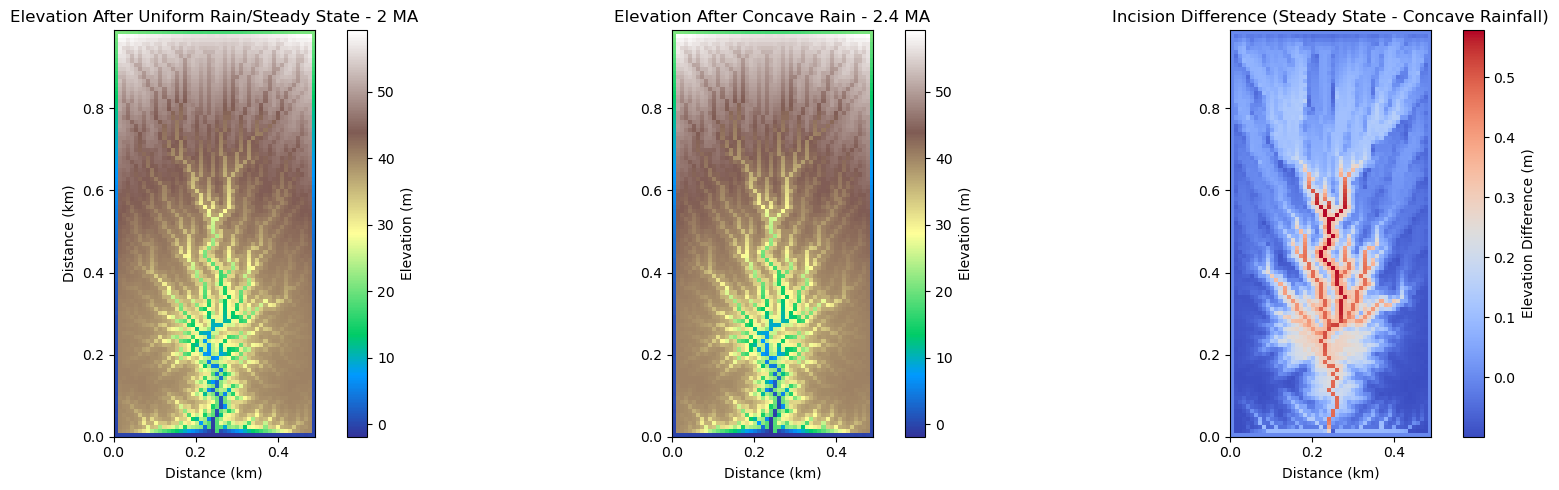

Animation: Uniform Rainfall Phase - 2 MA


Animation: Concave Rainfall Phase 2.04 MA


Running flow accumulation and lateral erosion analysis...


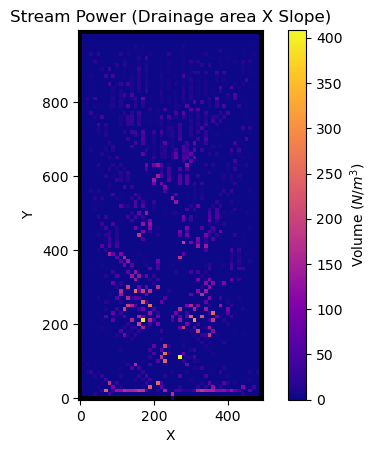


Running : 0.0 m/yr rainfall, infiltration 0.0% for 1 years


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 25.00it/s]


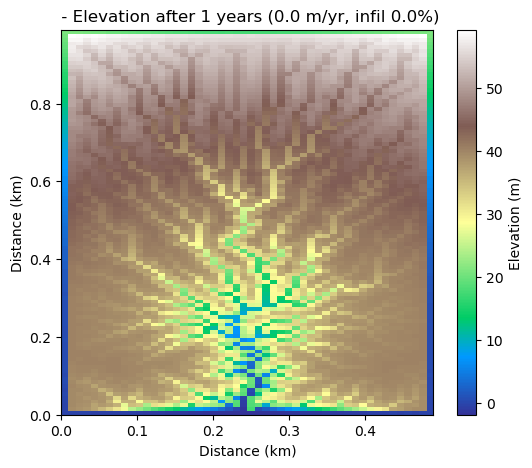

In [7]:
##Do not touch
# if __name__ == "__main__":
mg = main()  # store the main() output as mg

In [8]:
from landlab.components import OverlandFlow, FlowAccumulator
from landlab import RasterModelGrid, imshow_grid, imshow_grid_at_node
from landlab.components import FlowAccumulator, ChannelProfiler
from landlab.components.overland_flow import OverlandFlow
from landlab.plot.drainage_plot import drainage_plot
from landlab.utils import get_watershed_mask

In [9]:
# calculate the flow accumulation
# I would like the mg it routes to be the output of mg_A
# mg = mg_A()  remove this line
fa=FlowAccumulator( mg, method='Steepest', 
                    flow_director='FlowDirectorSteepest', 
                    depression_finder='LakeMapperBarnes',
                    redirect_flow_steepest_descent=True,
                    reaccumulate_flow=True)
fa.run_one_step()  



Text(0, 0.5, 'north-south distance (m)')

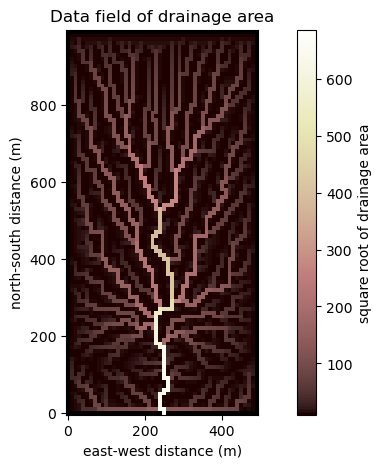

In [10]:
# plot the flow accumulation result
plt.figure(figsize=(10,5))
ax = plt.gca()
# ax.invert_yaxis()
imshow_grid(
    mg,
    np.sqrt(mg.at_node["drainage_area"]),
    plot_name="Data field of drainage area",
    var_name="square root of drainage area",
)
ax.set_xlabel('east-west distance (m)')
ax.set_ylabel('north-south distance (m)')


In [11]:
# set up channel profiler 
profiler = ChannelProfiler(mg,number_of_watersheds=1)
profiler.run_one_step()

In [12]:
# get watershed mask
outlet = profiler.nodes[0][0]
watershed_mask = get_watershed_mask(mg, outlet)

In [13]:
# set watershed boundary
mg.at_node["topographic__elevation"][~watershed_mask] = -9999.0
mg.status_at_node[~watershed_mask] = mg.BC_NODE_IS_CLOSED
mg.status_at_node[outlet] = mg.BC_NODE_IS_FIXED_VALUE

Text(0, 0.5, 'north-south distance (m)')

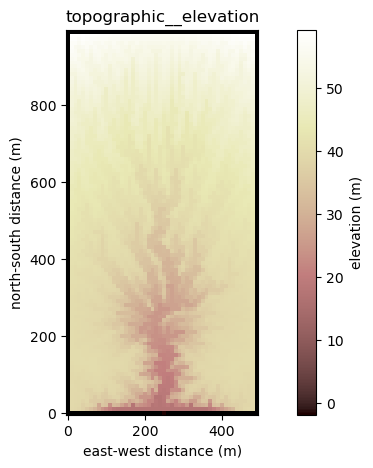

In [14]:
# plot the watershed 
plt.figure(figsize=(10,5))
ax = plt.gca()
# ax.invert_yaxis()
imshow_grid_at_node(mg, "topographic__elevation", 
                    plot_name='Topographic elevation of the watershed',
                    colorbar_label="elevation (m)")

ax.set_xlabel('east-west distance (m)')
ax.set_ylabel('north-south distance (m)')

In [15]:
# outlet id for watershed
print(outlet)

25


Tians notebooks shes shared: https://github.com/gantian127/flood_simulator/blob/master/flood_simulator.py#L198



Running storm: Decadal Scale Storm: 43204.618080311346it [00:13, 3179.19it/s]   
Running storm: Average Scale: 43204.29210665869it [00:10, 4300.53it/s]          
Running storm: Lower than Average Storm: 43211.17133664265it [00:07, 6130.66it/s]



=== Water Discharge Summary ===

Decadal Scale Storm:
  Peak Discharge: 7.2065e-01 m^3/s
  Mean Discharge: 2.2325e-01 m^3/s
  Total Volume:   5.9311e+03 m^3

Average Scale:
  Peak Discharge: 8.6197e-02 m^3/s
  Mean Discharge: 3.9746e-02 m^3/s
  Total Volume:   1.3066e+03 m^3

Lower than Average Storm:
  Peak Discharge: 9.2522e-03 m^3/s
  Mean Discharge: 7.0188e-03 m^3/s
  Total Volume:   2.5067e+02 m^3

=== Total Sediment Export ===
Decadal Scale Storm: 5.6139e+06
Average Scale: 5.6137e+06
Lower than Average Storm: 5.6146e+06

=== Peak Sediment Flux ===
Decadal Scale Storm: 1.2998e+02
Average Scale: 1.2998e+02
Lower than Average Storm: 1.2998e+02


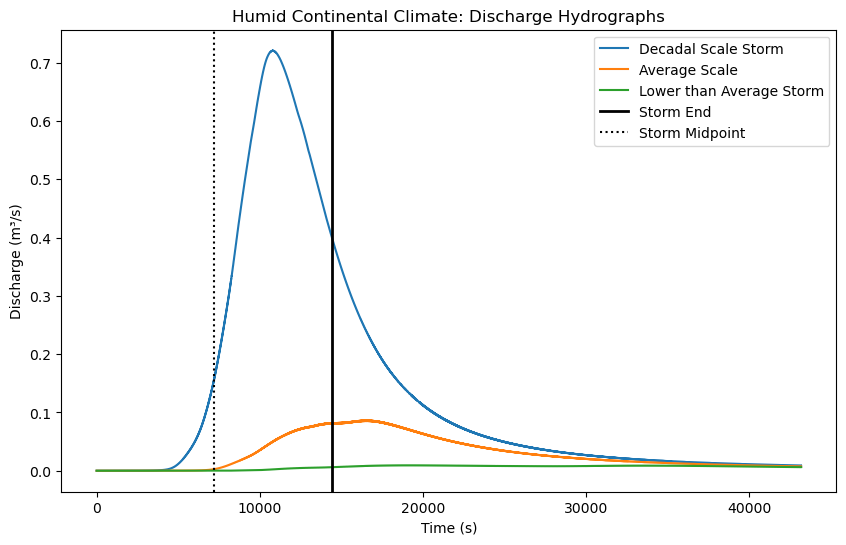


CSV exported to: hydrograph_outputs/hydrograph_excel_average_1mm.csv


In [19]:
# ==================== SECTION D: Storm Runoff + Sediment Comparison ====================

from landlab.components import OverlandFlow, FlowAccumulator
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

# ==================== INITIALIZE ====================
mg.add_zeros("surface_water__depth", at="node", clobber=True)

fa = FlowAccumulator(mg)

# ---------------- Storm setup ----------------
storm_duration = 14400.0          # seconds
starting_precip_mmhr = 2.5

# Convert rainfall to m/s
starting_precip_ms = starting_precip_mmhr / 1000 / 3600

model_run_time = 43200.0

rain_small = starting_precip_ms * 0.5
rain_original = starting_precip_ms
rain_large = starting_precip_ms * 3.0

# ---- Infiltration (, m/s) ----
#infilt = grid.add_zeros("soil_water_infiltration__depth", at="node")
infiltration_rate = 1.0e-7   # ~0.36 mm/hr

scenario_list = {
    "Decadal Scale Storm": rain_large,
    "Average Scale": rain_original,
    "Lower than Average Storm": rain_small,
}

# ==================== STORAGE ====================
all_hydrographs = {}
sediment_outputs = {}
peak_sediment = {}

# Exponents
m, n = 1.0, 1.0

# ==================== RUN ====================
for label, rain_intensity in scenario_list.items():

    mg.at_node["surface_water__depth"].fill(1e-6)

    of = OverlandFlow(mg, mannings_n=0.03, steep_slopes=True)

    hydro_t, hydro_q = [], []

    elapsed_time = 0.0
    total_sed_series = []
    max_sed = -np.inf

    with tqdm(total=model_run_time, desc=f"Running storm: {label}") as pbar:

        while elapsed_time < model_run_time:

            of.dt = of.calc_time_step()

            # ---------------- TRIANGULAR RAINFALL ----------------
            if elapsed_time < storm_duration:
                if elapsed_time <= storm_duration / 2:
                    rain_factor = elapsed_time / (storm_duration / 2)
                else:
                    rain_factor = (storm_duration - elapsed_time) / (storm_duration / 2)

                rainfall = rain_intensity * rain_factor
            else:
                rainfall = 0.0

            # ---------------- APPLY INFILTRATION ----------------
            effective_rain = max(0.0, rainfall - infiltration_rate)
            of.rainfall_intensity = effective_rain

            # ---------------- RUN MODEL ----------------
            of.run_one_step()
            fa.run_one_step()

            # ---------------- HYDRAULICS ----------------
            discharge = of.discharge_mapper(
                mg.at_link["surface_water__discharge"],
                convert_to_volume=True
            )

            slope = mg.calc_grad_at_link("topographic__elevation")
            slope_node = mg.map_mean_of_links_to_node(slope)

            # ---- prevent negative slope issues ----
            slope_node = np.maximum(slope_node, 0)

            A = mg.at_node["drainage_area"]

            # ---------------- SEDIMENT ----------------
            sed_flux = (A**m) * (slope_node**n)

            q_out = discharge[outlet]
            sed_out = sed_flux[outlet]

            hydro_t.append(elapsed_time)
            hydro_q.append(q_out)
            total_sed_series.append(sed_out)

            if sed_out > max_sed:
                max_sed = sed_out

            elapsed_time += of.dt
            pbar.update(of.dt)

    # ---- STORE RESULTS ----
    all_hydrographs[label] = (np.array(hydro_t), np.array(hydro_q))
    sediment_outputs[label] = np.trapz(total_sed_series, hydro_t)
    peak_sediment[label] = max_sed


# ==================== RESULTS ====================
print("\n=== Water Discharge Summary ===")
for label, (t, q) in all_hydrographs.items():
    print(f"\n{label}:")
    print(f"  Peak Discharge: {np.max(q):.4e} m^3/s")
    print(f"  Mean Discharge: {np.mean(q):.4e} m^3/s")
    print(f"  Total Volume:   {np.trapz(q, t):.4e} m^3")

print("\n=== Total Sediment Export ===")
for k, v in sediment_outputs.items():
    print(f"{k}: {v:.4e}")

print("\n=== Peak Sediment Flux ===")
for k, v in peak_sediment.items():
    print(f"{k}: {v:.4e}")


# ==================== PLOT ====================
plt.figure(figsize=(10,6))
for label, (t, q) in all_hydrographs.items():
    plt.plot(t, q, label=label)

plt.axvline(storm_duration, color="k", linestyle="-", linewidth=2, label="Storm End")
plt.axvline(storm_duration/2, color="k", linestyle=":", label="Storm Midpoint")

plt.title("Humid Continental Climate: Discharge Hydrographs")
plt.xlabel("Time (s)")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.show()


# ==================== EXPORT (EXCEL-READY CSV) ====================

# ---- Create common time base (interpolated for clean Excel plotting) ----
dt_common = 10  # seconds
common_time = np.arange(0, model_run_time, dt_common)

data_columns = [common_time]
headers = ["time_s"]

for label, (t, q) in all_hydrographs.items():
    q_interp = np.interp(common_time, t, q)
    data_columns.append(q_interp)
    headers.append(label)


output = np.column_stack(data_columns)

# ---- Save CSV ----
output_dir = "hydrograph_outputs"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "hydrograph_excel_average_1mm.csv")

np.savetxt(
    csv_path,
    output,
    delimiter=",",
    header=",".join(headers),
    comments=""
)

print(f"\nCSV exported to: {csv_path}")